In [ ]:
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "paths.py").exists())
sys.path.insert(0, str(ROOT))
from paths import *


# Reference set


## Config


In [ ]:
# research-grade iNaturalist observations for the three dune species,
# prepared as the held-out set for FID and KID.
#
# the pool is finite and the training images came from it, so a fresh
# download returns many of the same observations. any overlap means
# scoring a model against images it trained on. exclude by observation id
# if available, md5 as a backstop.

import os, json, time, hashlib
from pathlib import Path

ROOT   = str(ROOT)
REF = os.path.join(ROOT, "data/reference")
RAW_DIR       = "/content/inat_raw"        

# Training data, for the leakage check.
TRAIN = os.path.join(ROOT, "data/train")

# JSON or text file of iNaturalist observation IDs used in training.
# None if it doesn't exist, the md5 check still runs
TRAIN_OBS_IDS_PATH = None

SPECIES = {
    "achillea":    "Achillea maritima",
    "carpobrotus": "Carpobrotus acinaciformis",
    "eryngium":    "Eryngium maritimum",
}

TARGET_PER_SPECIES = 200
LICENCES = ["cc0", "cc-by", "cc-by-nc"]
RES = 512          # must match training preprocessing resolution
PHOTO_SIZE = "large"      # large is ~1024px; 

os.makedirs(RAW_DIR, exist_ok=True)
os.makedirs(REF, exist_ok=True)

print("target:", TARGET_PER_SPECIES, "images per species")
print("species:", ", ".join(SPECIES.values()))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Target: 200 images per species
Species: Achillea maritima, Carpobrotus acinaciformis, Eryngium maritimum


## Training observation ids


In [ ]:

train_obs_ids = set()

if TRAIN_OBS_IDS_PATH and os.path.exists(TRAIN_OBS_IDS_PATH):
    with open(TRAIN_OBS_IDS_PATH) as f:
        if TRAIN_OBS_IDS_PATH.endswith(".json"):
            data = json.load(f)
            if isinstance(data, dict):
                data = [v for vals in data.values() for v in vals]
            train_obs_ids = {int(x) for x in data}
        else:
            train_obs_ids = {int(line.strip()) for line in f if line.strip()}
    print(f"{len(train_obs_ids)} training observation IDs loaded for exclusion")
else:
    print("No observation ID list. Falling back to MD5 deduplication only.")
    print("for the limitations: near-dupes from the same")
    print("observation will not be caught.")


No observation ID list. Falling back to MD5 deduplication only.
Note this in the limitations: near-duplicates from the same
observation will not be caught.


## Query the API


In [ ]:
# over-fetch on as some images are excluded, whilst downloads may fail. per_page caps at 200. 
import requests

API = "https://api.inaturalist.org/v1/observations"
HEADERS = {"User-Agent": "MSc-dissertation-reference-set/1.0"}

def fetch_observations(scientific_name, target, exclude_ids):
    """Return observation records with usable photos, excluding training IDs."""
    kept, page = [], 1
    seen_ids = set()

    while len(kept) < target * 3 and page <= 20:
        params = {
            "taxon_name": scientific_name,
            "quality_grade": "research",
            "photo_license": ",".join(LICENCES),
            "photos": "true",
            "per_page": 200,
            "page": page,
            "order_by": "id",
            "order": "desc",
        }
        r = requests.get(API, params=params, headers=HEADERS, timeout=60)
        r.raise_for_status()
        payload = r.json()
        results = payload.get("results", [])
        if not results:
            break

        for obs in results:
            oid = obs["id"]
            if oid in exclude_ids or oid in seen_ids:
                continue
            photos = obs.get("photos") or []
            if not photos:
                continue
            seen_ids.add(oid)
            kept.append({
                "observation_id": oid,
                "photo_url": photos[0]["url"].replace("square", PHOTO_SIZE),
                "licence": photos[0].get("license_code"),
                "attribution": photos[0].get("attribution"),
                "taxon": obs.get("taxon", {}).get("name"),
                "observed_on": obs.get("observed_on"),
            })

        total = payload.get("total_results", 0)
        print(f"    page {page}: {len(results)} results, "
              f"{len(kept)} usable so far (total available {total})")
        if page * 200 >= total:
            break
        page += 1
        time.sleep(1.0)

    return kept

candidates = {}
for key, sci in SPECIES.items():
    print(f"\n{sci}")
    obs = fetch_observations(sci, TARGET_PER_SPECIES, train_obs_ids)
    candidates[key] = obs
    print(f"  {len(obs)} candidate observations after ID exclusion")
    if len(obs) < TARGET_PER_SPECIES:
        print(f"  short of {TARGET_PER_SPECIES}")



Achillea maritima
    page 1: 200 results, 200 usable so far (total available 1736)
    page 2: 200 results, 400 usable so far (total available 1736)
    page 3: 200 results, 600 usable so far (total available 1736)
  600 candidate observations after ID exclusion

Carpobrotus acinaciformis
    page 1: 200 results, 200 usable so far (total available 2229)
    page 2: 200 results, 400 usable so far (total available 2229)
    page 3: 200 results, 600 usable so far (total available 2229)
  600 candidate observations after ID exclusion

Eryngium maritimum
    page 1: 200 results, 200 usable so far (total available 11227)
    page 2: 200 results, 400 usable so far (total available 11227)
    page 3: 200 results, 600 usable so far (total available 11227)
  600 candidate observations after ID exclusion


## Download


In [ ]:
# one photo per observation in order to prevent two reference images from being the same plant
def download(records, dest, limit):
    dest = Path(dest)
    dest.mkdir(parents=True, exist_ok=True)
    manifest, ok = [], 0

    for rec in records:
        if ok >= limit:
            break
        try:
            r = requests.get(rec["photo_url"], headers=HEADERS, timeout=60)
            r.raise_for_status()
        except Exception as e:
            print(f"    failed {rec['observation_id']}: {e}")
            continue

        path = dest / f"{rec['observation_id']}.jpg"
        path.write_bytes(r.content)
        rec = dict(rec, filename=path.name,
                   md5=hashlib.md5(r.content).hexdigest())
        manifest.append(rec)
        ok += 1
        if ok % 25 == 0:
            print(f"    {ok}/{limit}")
        time.sleep(0.3)

    return manifest

manifests = {}
for key, records in candidates.items():
    print(f"\n{key}")
    manifests[key] = download(records, Path(RAW_DIR) / key,
                              TARGET_PER_SPECIES + 30)   # margin for failures
    print(f"  {len(manifests[key])} downloaded")



achillea
    25/230
    50/230
    75/230
    100/230
    125/230
    150/230
    175/230
    200/230
    225/230
  230 downloaded

carpobrotus
    25/230
    50/230
    75/230
    100/230
    125/230
    150/230
    175/230
    200/230
    225/230
  230 downloaded

eryngium
    25/230
    50/230
    75/230
    100/230
    125/230
    150/230
    175/230
    200/230
    225/230
  230 downloaded


## Leakage check


In [ ]:
# md5 against the training set. catches exacted duplications solely
EXTS = {".jpg", ".jpeg", ".png", ".webp"}

def hash_dir(root):
    p = Path(root)
    if not p.exists():
        return set()
    return {hashlib.md5(f.read_bytes()).hexdigest()
            for f in p.rglob("*") if f.suffix.lower() in EXTS}

if TRAIN and os.path.exists(TRAIN):
    train_hashes = hash_dir(TRAIN)
    print(f"{len(train_hashes)} unique training images\n")

    for key, manifest in manifests.items():
        leaked = [m for m in manifest if m["md5"] in train_hashes]
        for m in leaked:
            (Path(RAW_DIR) / key / m["filename"]).unlink(missing_ok=True)
        manifests[key] = [m for m in manifest if m["md5"] not in train_hashes]
        status = f"{len(leaked)} LEAKED, removed" if leaked else "clean"
        print(f"  {key:<12} {status}  -> {len(manifests[key])} remain")
else:
    print("TRAIN missing. MD5 check NOT run.")
    print("")


REFERENCE
  achillea         200 images
  carpobrotus      200 images
  eryngium         200 images

GENERATED


NameError: name 'LORA_DIR' is not defined

## Crop and resize


In [ ]:
# same square centre crop as the training images. leave the reference set
# uncropped and FID picks up the framing difference as a distribution gap.
from PIL import Image

def prepare(manifest, src, dest, limit):
    dest = Path(dest)
    dest.mkdir(parents=True, exist_ok=True)
    for f in dest.glob("*"):
        f.unlink()

    written = []
    for rec in manifest:
        if len(written) >= limit:
            break
        path = Path(src) / rec["filename"]
        try:
            im = Image.open(path).convert("RGB")
        except Exception as e:
            print(f"    skipping {rec['filename']}: {e}")
            continue

        w, h = im.size
        if min(w, h) < RES:
            continue                      
        side = min(w, h)
        im = im.crop(((w - side) // 2, (h - side) // 2,
                      (w + side) // 2, (h + side) // 2))
        im = im.resize((RES, RES), Image.BICUBIC)

        out = dest / f"{rec['observation_id']}.png"
        im.save(out)
        written.append(dict(rec, output=out.name))
    return written

final = {}
for key in SPECIES:
    out_dir = Path(REF) / key
    final[key] = prepare(manifests[key], Path(RAW_DIR) / key,
                         out_dir, TARGET_PER_SPECIES)
    print(f"  {key:<12} {len(final[key]):>4} images -> {out_dir}")


  achillea      200 images -> /content/drive/MyDrive/Synthetic_Plants_Project/test_images/achillea
  carpobrotus   200 images -> /content/drive/MyDrive/Synthetic_Plants_Project/test_images/carpobrotus
  eryngium      200 images -> /content/drive/MyDrive/Synthetic_Plants_Project/test_images/eryngium


## Manifest


In [7]:
# observation ids, licences, attribution. needed for the acknowledgements
# and to rebuild the set later.
manifest_path = os.path.join(ROOT, "outputs/metrics",
                             "reference_set_manifest.json")
os.makedirs(os.path.dirname(manifest_path), exist_ok=True)

with open(manifest_path, "w") as f:
    json.dump({
        "species": SPECIES,
        "target_per_species": TARGET_PER_SPECIES,
        "licences": LICENCES,
        "resolution": RES,
        "obs_id_exclusion": bool(train_obs_ids),
        "n_excluded_ids": len(train_obs_ids),
        "images": {k: v for k, v in final.items()},
    }, f, indent=2)

print("manifest:", manifest_path)
print()
for key, recs in final.items():
    lic = {}
    for r in recs:
        lic[r["licence"]] = lic.get(r["licence"], 0) + 1
    print(f"  {key:<12} {len(recs):>4} images   licences: {lic}")


Manifest: /content/drive/MyDrive/Synthetic_Plants_Project/Data_Clean/reference_set_manifest.json

  achillea      200 images   licences: {'cc-by-nc': 180, 'cc-by': 20}
  carpobrotus   200 images   licences: {'cc-by-nc': 185, 'cc-by': 15}
  eryngium      200 images   licences: {'cc-by-nc': 178, 'cc-by': 18, 'cc0': 4}


## Observation Display


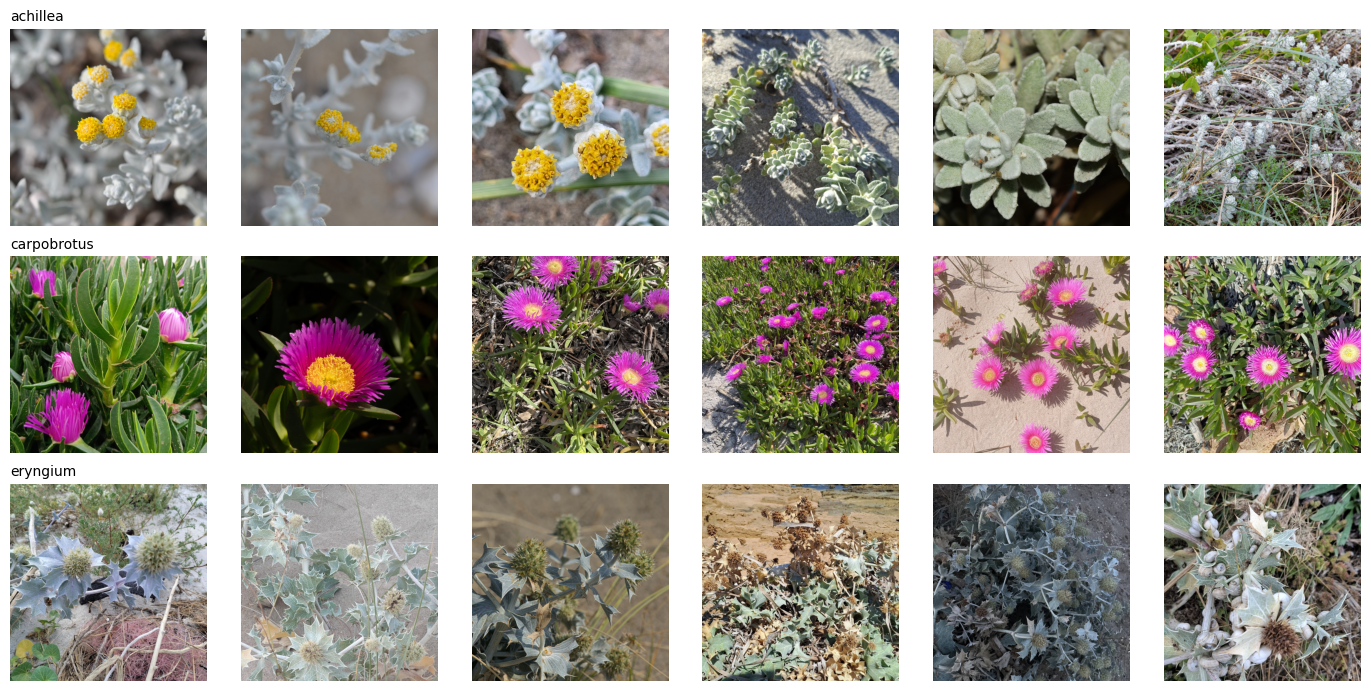

In [8]:
# herbarium sheets, multi-species frames and landscape shots all pass the
# research-grade filter and none of them are comparable to the generated set
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 6, figsize=(14, 7))
for row, key in enumerate(SPECIES):
    files = sorted((Path(REF) / key).glob("*.png"))[:6]
    for col, ax in enumerate(axes[row]):
        ax.axis("off")
        if col < len(files):
            ax.imshow(Image.open(files[col]))
            if col == 0:
                ax.set_title(key, loc="left", fontsize=10)
plt.tight_layout()
plt.show()
